<a href="https://colab.research.google.com/github/Gustavo-Thiago/rotina_complexos/blob/main/Trab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

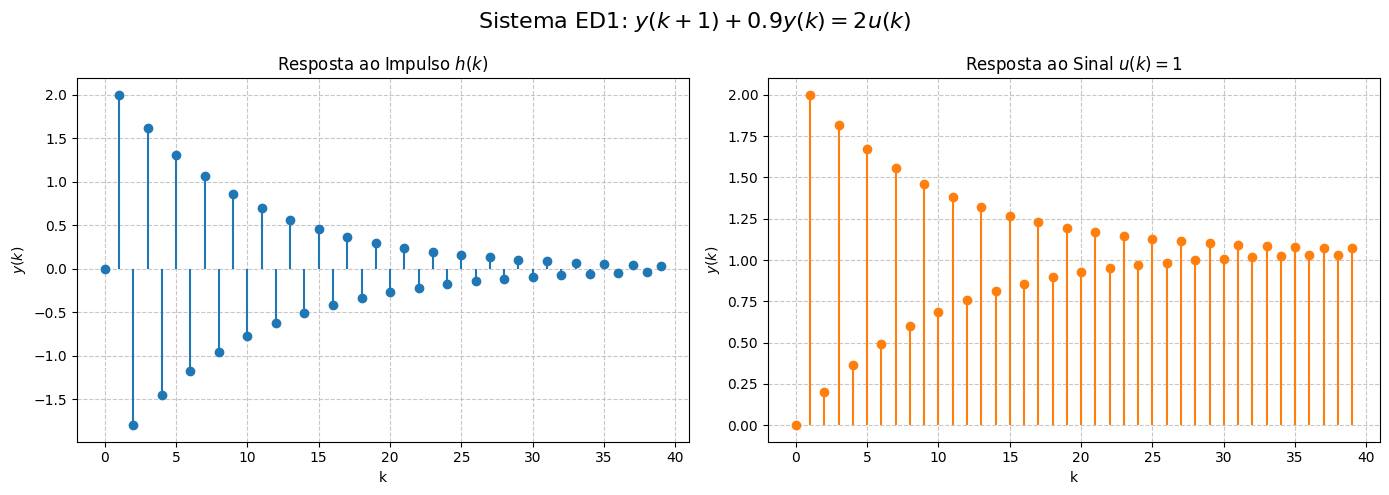

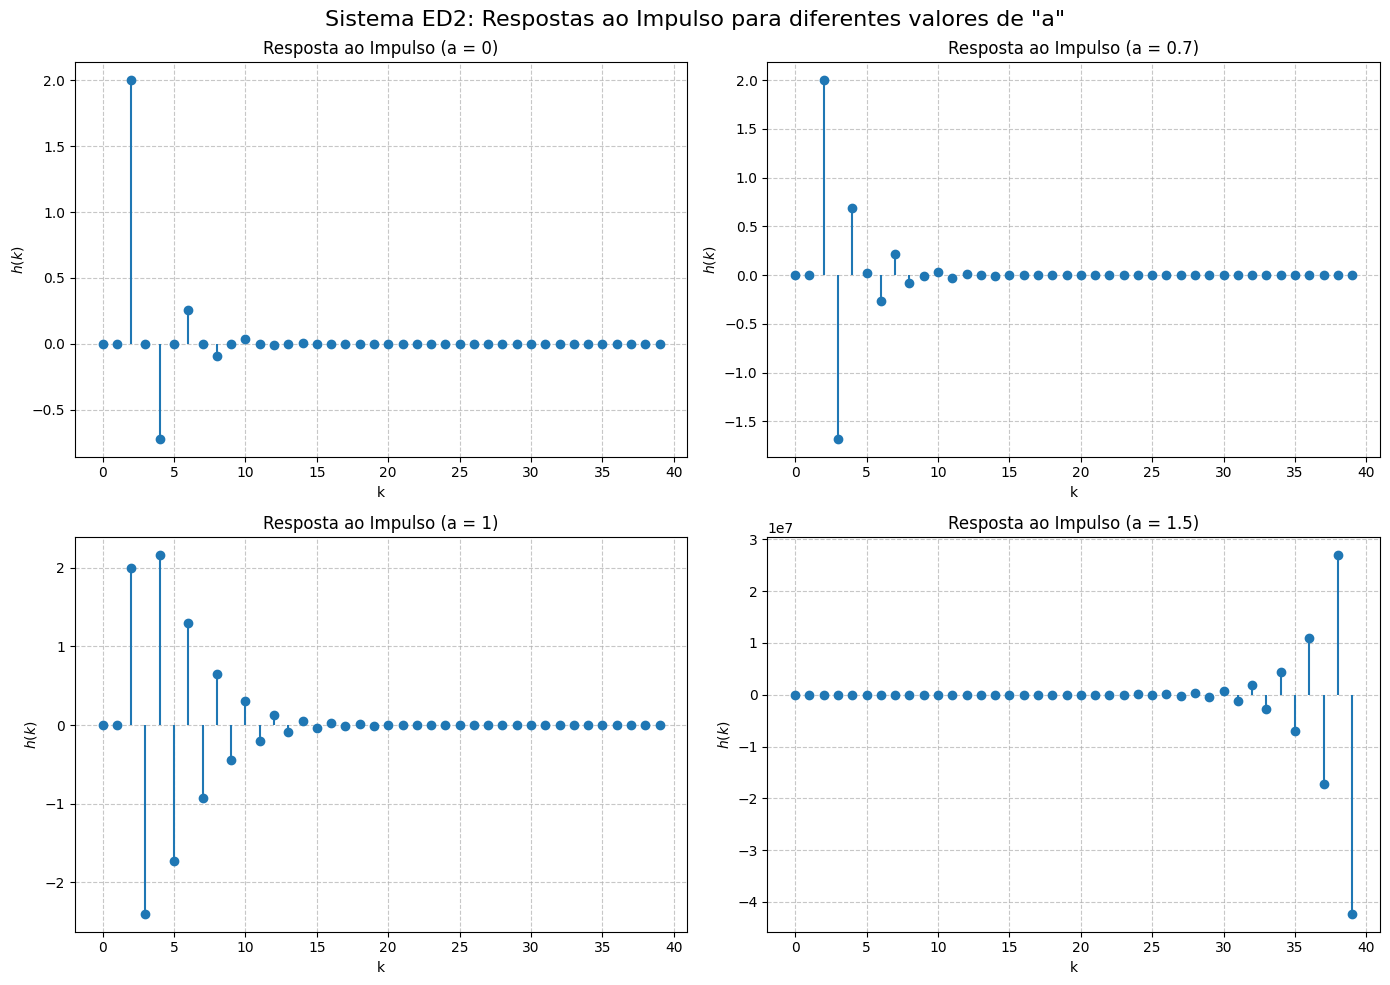

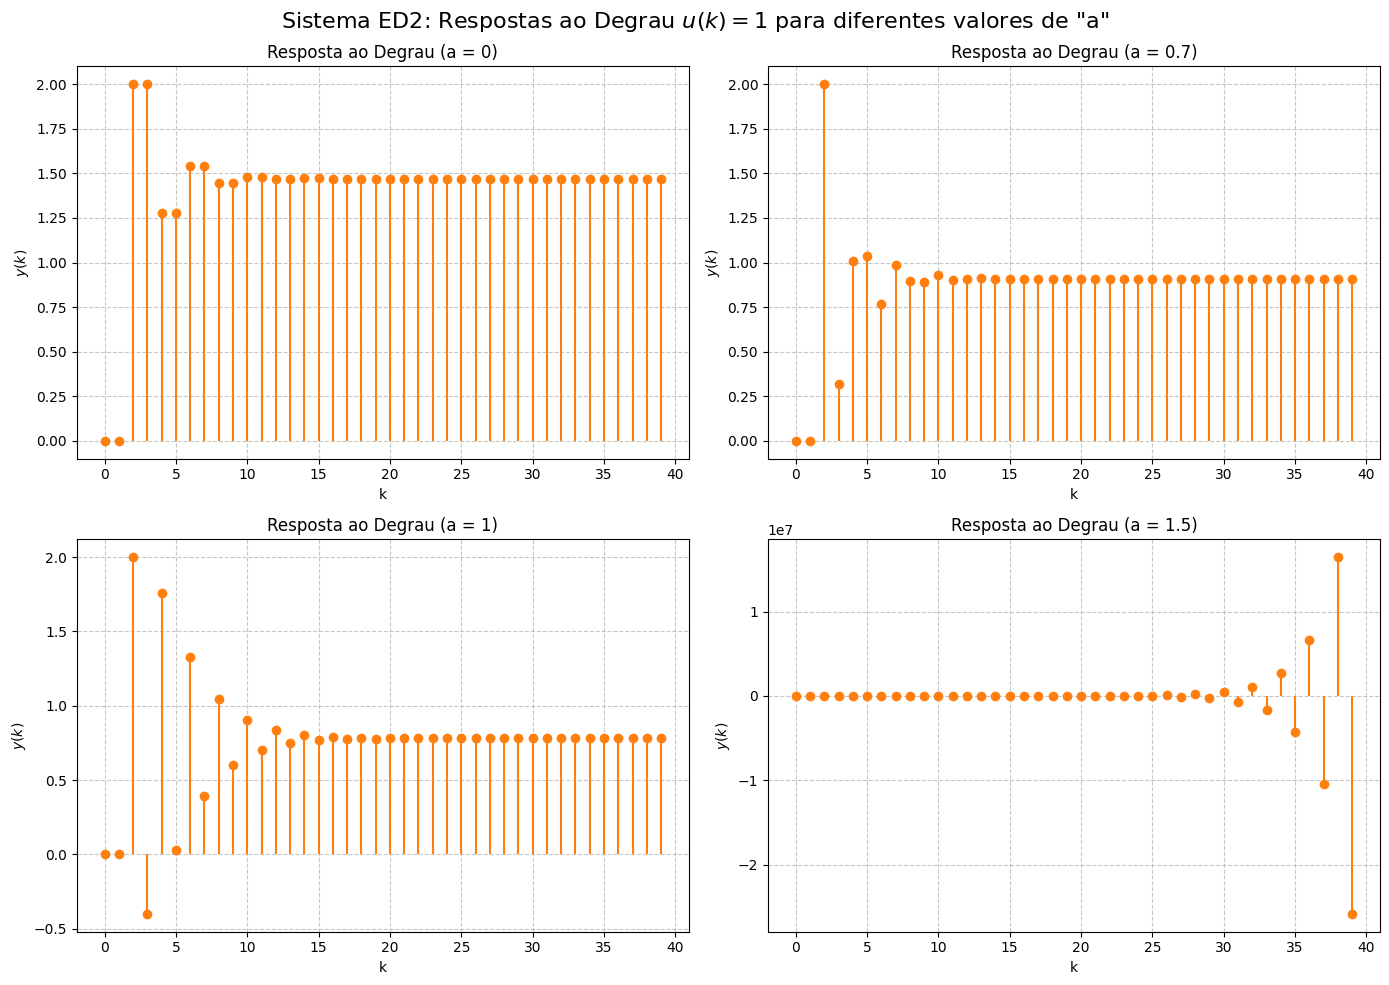

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros de Simulação
N = 40 # Número de amostras
k = np.arange(N) # Vetor de tempo discreto k = 0, 1, ..., N-1

# Definindo os sinais de entrada
# Impulso: u(0) = 1, u(k) = 0 para k > 0
u_impulso = np.zeros(N)
u_impulso[0] = 1

# Degrau unitário: u(k) = 1 para todo k >= 0
u_degrau = np.ones(N)

# 1. Sistema ED1: y(k+1) + 0.9y(k) = 2u(k)
# Isolando y(k+1): y(k+1) = -0.9y(k) + 2u(k)
def simula_ed1(u):
    y = np.zeros(N)
    for i in range(N - 1):
        y[i + 1] = -0.9 * y[i] + 2 * u[i]
    return y

# Calculando as respostas
h_ed1 = simula_ed1(u_impulso)
y_ed1_degrau = simula_ed1(u_degrau)

# Plotando ED1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sistema ED1: $y(k+1) + 0.9y(k) = 2u(k)$', fontsize=16)

ax1.stem(k, h_ed1, basefmt=" ")
ax1.set_title('Resposta ao Impulso $h(k)$')
ax1.set_xlabel('k')
ax1.set_ylabel('$y(k)$')
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.stem(k, y_ed1_degrau, basefmt=" ", linefmt='C1-', markerfmt='C1o')
ax2.set_title('Resposta ao Sinal $u(k)=1$')
ax2.set_xlabel('k')
ax2.set_ylabel('$y(k)$')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 2. Sistema ED2: y(k+2) + (1.2a)y(k+1) + 0.36y(k) = 2u(k)
# Isolando y(k+2): y(k+2) = -(1.2a)y(k+1) - 0.36y(k) + 2u(k)
def simula_ed2(u, a):
    y = np.zeros(N)
    for i in range(N - 2):
        y[i + 2] = -(1.2 * a) * y[i + 1] - 0.36 * y[i] + 2 * u[i]
    return y

valores_a = [0, 0.7, 1, 1.5]

# Plotando ED2 (Uma figura para Impulso, outra para Degrau)
fig_imp, axes_imp = plt.subplots(2, 2, figsize=(14, 10))
fig_imp.suptitle('Sistema ED2: Respostas ao Impulso para diferentes valores de "a"', fontsize=16)

fig_deg, axes_deg = plt.subplots(2, 2, figsize=(14, 10))
fig_deg.suptitle('Sistema ED2: Respostas ao Degrau $u(k)=1$ para diferentes valores de "a"', fontsize=16)

for idx, a in enumerate(valores_a):
    row, col = divmod(idx, 2)

    # Simulações
    h_ed2 = simula_ed2(u_impulso, a)
    y_ed2_degrau = simula_ed2(u_degrau, a)

    # Plot Impulso
    ax = axes_imp[row, col]
    ax.stem(k, h_ed2, basefmt=" ")
    ax.set_title(f'Resposta ao Impulso (a = {a})')
    ax.set_xlabel('k')
    ax.set_ylabel('$h(k)$')
    ax.grid(True, linestyle='--', alpha=0.7)

    # Plot Degrau
    ax = axes_deg[row, col]
    ax.stem(k, y_ed2_degrau, basefmt=" ", linefmt='C1-', markerfmt='C1o')
    ax.set_title(f'Resposta ao Degrau (a = {a})')
    ax.set_xlabel('k')
    ax.set_ylabel('$y(k)$')
    ax.grid(True, linestyle='--', alpha=0.7)

fig_imp.tight_layout()
fig_deg.tight_layout()
plt.show()